<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pratica2Quest%C3%A3o10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baixando handel.wav de https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_02/Sinais_Usados/handel.wav ...
Download concluido.
handel.wav: fs = 8192 Hz, N = 73113 amostras, duracao = 8.925 s
Baixando sinal_taca.wav de https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_02/Sinais_Usados/sinal_taca.wav ...
Download concluido.
sinal_taca.wav: fs = 22050 Hz, N = 19100 amostras, duracao = 0.866 s
Baixando h_banheiro.wav de https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_02/Sinais_Usados/h_banheiro.wav ...
Download concluido.
h_banheiro.wav: fs = 22050 Hz, N = 9475 amostras, duracao = 0.430 s

Frequencia de amostragem alvo (do h_banheiro.wav): 22050 Hz
handel.wav reamostrado: 8192 Hz -> 22050 Hz (73113 -> 196795 amostras)
sinal_taca.wav: ja estava em 22050 Hz (igual a fs_alvo, sem necessidade de reamostragem)

y_handel = handel * h_banheiro: N = 206269 amostras, duracao = 9.355 s
y_taca   = taca   * h_ban

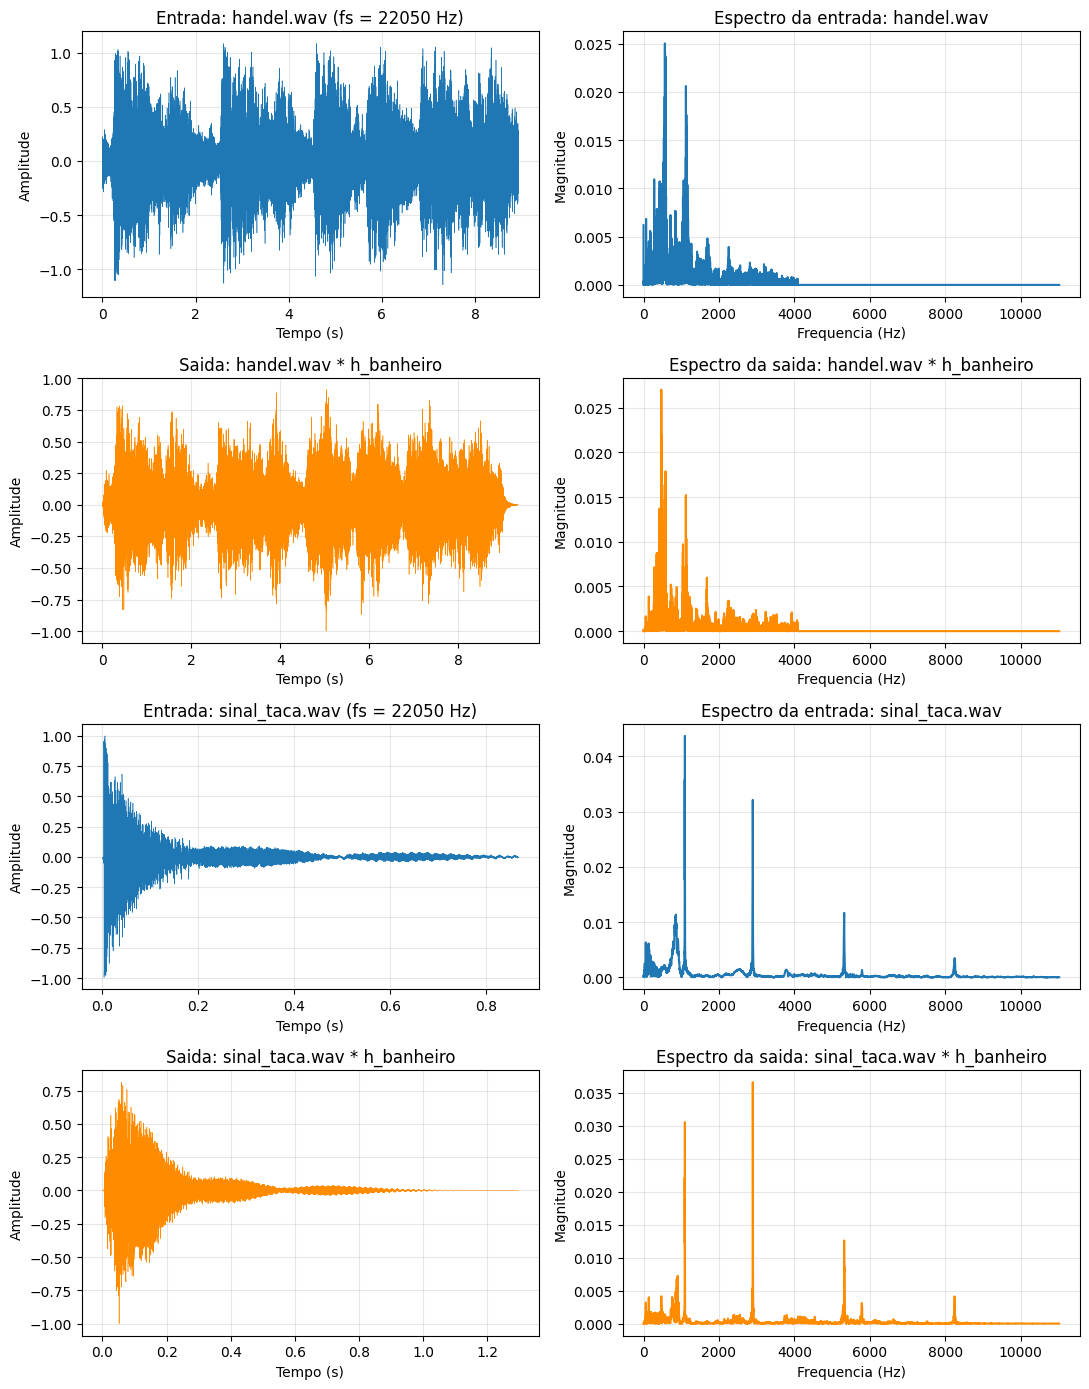


--- handel.wav (entrada original) ---


--- handel.wav * h_banheiro (resposta / 'handel dentro do banheiro') ---



--- sinal_taca.wav (entrada original) ---


--- sinal_taca.wav * h_banheiro (resposta / 'taca dentro do banheiro') ---


In [ ]:
"""
Questao 10 - Resposta de h_banheiro[n] para as entradas handel.wav e sinal_taca.wav

Conceito:
    h_banheiro[n] e a resposta ao impulso (RIR) do banheiro (Questao 9).
    "Calcular a resposta do sistema para uma entrada x[n]" significa calcular
    a SAIDA do sistema linear invariante no tempo (LTI) representado por
    h_banheiro[n], quando excitado por x[n]. Isso e feito via CONVOLUCAO:

        y[n] = x[n] * h[n] = soma_k  x[k] * h[n-k]

    Na pratica, y[n] representa "como o audio x[n] soaria se fosse tocado
    dentro do banheiro" (aplicando a reverberacao do ambiente ao som original).

Atencao (dica do enunciado):
    Para convoluir dois sinais discretos corretamente, ambos precisam estar
    na MESMA frequencia de amostragem. Como h_banheiro.wav, handel.wav e
    sinal_taca.wav podem ter fs diferentes entre si (nas questoes anteriores,
    handel.wav tinha fs = 8192 Hz e h_banheiro.wav / sinal_taca.wav tinham
    fs = 22050 Hz), e necessario reamostrar um dos sinais antes de convoluir,
    usando scipy.signal.resample() para casar as taxas de amostragem.

Objetivo:
    (a) Calcular y1[n] = handel[n] * h_banheiro[n]
        e   y2[n] = taca[n]   * h_banheiro[n]
        e, para cada resposta, calcular o espectro via calculate_spectrum()
    (b) Comentar os resultados obtidos
"""

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import resample, fftconvolve
import IPython.display as ipd


# ---------------------------------------------------------------------------
# Funcao calculate_spectrum (mesma das questoes anteriores)
# ---------------------------------------------------------------------------
def calculate_spectrum(x, fs):
    """
    Calcula o espectro de magnitude de um sinal discreto x[n] amostrado a fs.
    Retorna freqs (Hz, parte positiva 0 a fs/2) e mag (magnitude normalizada).
    """
    N = len(x)
    X = np.fft.fft(x)
    freqs_completo = np.fft.fftfreq(N, d=1/fs)
    metade = N // 2
    freqs = freqs_completo[:metade]
    mag = (2.0 / N) * np.abs(X[:metade])
    return freqs, mag


# ---------------------------------------------------------------------------
# Funcao auxiliar para ler e normalizar um arquivo .wav
# ---------------------------------------------------------------------------
def ler_wav(caminho):
    """Le um .wav e retorna (fs, x), normalizado entre -1 e 1 e em mono."""
    fs, x = wavfile.read(caminho)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float64)
    x = x / np.max(np.abs(x))
    return fs, x


def casar_fs(x, fs_x, fs_alvo):
    """
    Reamostra o sinal x (originalmente a fs_x) para a frequencia fs_alvo,
    usando scipy.signal.resample (reamostragem via FFT).
    Necessario para garantir que dois sinais estejam na mesma fs antes
    de serem convoluidos (ver dica do enunciado).
    """
    if fs_x == fs_alvo:
        return x   # ja esta na frequencia correta, nao precisa reamostrar
    N_novo = int(round(len(x) * fs_alvo / fs_x))
    return resample(x, N_novo)


# ---------------------------------------------------------------------------
# Download/leitura dos tres arquivos de audio
# ---------------------------------------------------------------------------
usar_colab = True
base_url = ("https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/"
            "main/Aula_02/Sinais_Usados/")

arquivos = {
    "handel": "handel.wav",
    "taca": "sinal_taca.wav",
    "h_banheiro": "h_banheiro.wav",
}

sinais = {}
for nome, arquivo in arquivos.items():
    if usar_colab and not os.path.exists(arquivo):
        url = base_url + arquivo
        print(f"Baixando {arquivo} de {url} ...")
        urllib.request.urlretrieve(url, arquivo)
        print("Download concluido.")
    fs, x = ler_wav(arquivo)
    sinais[nome] = (fs, x)
    print(f"{arquivo}: fs = {fs} Hz, N = {len(x)} amostras, "
          f"duracao = {len(x)/fs:.3f} s")

fs_handel, x_handel = sinais["handel"]
fs_taca, x_taca = sinais["taca"]
fs_h, h_banheiro = sinais["h_banheiro"]


# ---------------------------------------------------------------------------
# Casar as frequencias de amostragem antes de convoluir (dica do enunciado)
# ---------------------------------------------------------------------------
# Escolhemos a fs de h_banheiro.wav como referencia, ja que ela representa
# o sistema (resposta ao impulso) que sera aplicado aos dois sinais de entrada.
fs_alvo = fs_h

x_handel_resampled = casar_fs(x_handel, fs_handel, fs_alvo)
x_taca_resampled = casar_fs(x_taca, fs_taca, fs_alvo)

print(f"\nFrequencia de amostragem alvo (do h_banheiro.wav): {fs_alvo} Hz")
print(f"handel.wav reamostrado: {fs_handel} Hz -> {fs_alvo} Hz "
      f"({len(x_handel)} -> {len(x_handel_resampled)} amostras)")
print(f"sinal_taca.wav: ja estava em {fs_taca} Hz "
      f"(igual a fs_alvo, sem necessidade de reamostragem)" if fs_taca == fs_alvo
      else f"sinal_taca.wav reamostrado: {fs_taca} Hz -> {fs_alvo} Hz")


# ---------------------------------------------------------------------------
# (a) Convolucao: y[n] = x[n] * h_banheiro[n], e espectro de cada resposta
# ---------------------------------------------------------------------------
# fftconvolve calcula a convolucao completa (modo 'full') de forma eficiente
# via FFT -- resultado equivalente a np.convolve, porem mais rapido para
# sinais longos (como e o caso de arquivos de audio).
y_handel = fftconvolve(x_handel_resampled, h_banheiro, mode='full')
y_taca = fftconvolve(x_taca_resampled, h_banheiro, mode='full')

# Normaliza as saidas para evitar estouro de amplitude (clipping) ao salvar/ouvir
y_handel = y_handel / np.max(np.abs(y_handel))
y_taca = y_taca / np.max(np.abs(y_taca))

print(f"\ny_handel = handel * h_banheiro: N = {len(y_handel)} amostras, "
      f"duracao = {len(y_handel)/fs_alvo:.3f} s")
print(f"y_taca   = taca   * h_banheiro: N = {len(y_taca)} amostras, "
      f"duracao = {len(y_taca)/fs_alvo:.3f} s")

# Espectro de cada resposta, via calculate_spectrum
freqs_y_handel, mag_y_handel = calculate_spectrum(y_handel, fs_alvo)
freqs_y_taca, mag_y_taca = calculate_spectrum(y_taca, fs_alvo)

# Espectros dos sinais de entrada originais (reamostrados), para comparacao
freqs_x_handel, mag_x_handel = calculate_spectrum(x_handel_resampled, fs_alvo)
freqs_x_taca, mag_x_taca = calculate_spectrum(x_taca_resampled, fs_alvo)


# ---------------------------------------------------------------------------
# Plots: entrada vs. saida (tempo e espectro), para os dois casos
# ---------------------------------------------------------------------------
fig, eixos = plt.subplots(4, 2, figsize=(11, 14))

pares = [
    ("handel", x_handel_resampled, y_handel,
     freqs_x_handel, mag_x_handel, freqs_y_handel, mag_y_handel),
    ("taca", x_taca_resampled, y_taca,
     freqs_x_taca, mag_x_taca, freqs_y_taca, mag_y_taca),
]

for i, (nome, x_in, y_out, freqs_in, mag_in, freqs_out, mag_out) in enumerate(pares):

    linha_entrada = 2 * i
    linha_saida = 2 * i + 1

    t_in = np.arange(len(x_in)) / fs_alvo
    t_out = np.arange(len(y_out)) / fs_alvo

    # --- Entrada: tempo e espectro ---
    eixos[linha_entrada, 0].plot(t_in, x_in, linewidth=0.4)
    eixos[linha_entrada, 0].set_title(f"Entrada: {arquivos[nome]} (fs = {fs_alvo} Hz)")
    eixos[linha_entrada, 0].set_xlabel("Tempo (s)")
    eixos[linha_entrada, 0].set_ylabel("Amplitude")
    eixos[linha_entrada, 0].grid(True, alpha=0.3)

    eixos[linha_entrada, 1].plot(freqs_in, mag_in)
    eixos[linha_entrada, 1].set_title(f"Espectro da entrada: {arquivos[nome]}")
    eixos[linha_entrada, 1].set_xlabel("Frequencia (Hz)")
    eixos[linha_entrada, 1].set_ylabel("Magnitude")
    eixos[linha_entrada, 1].grid(True, alpha=0.3)

    # --- Saida (apos convolucao com h_banheiro): tempo e espectro ---
    eixos[linha_saida, 0].plot(t_out, y_out, linewidth=0.4, color='darkorange')
    eixos[linha_saida, 0].set_title(f"Saida: {arquivos[nome]} * h_banheiro")
    eixos[linha_saida, 0].set_xlabel("Tempo (s)")
    eixos[linha_saida, 0].set_ylabel("Amplitude")
    eixos[linha_saida, 0].grid(True, alpha=0.3)

    eixos[linha_saida, 1].plot(freqs_out, mag_out, color='darkorange')
    eixos[linha_saida, 1].set_title(f"Espectro da saida: {arquivos[nome]} * h_banheiro")
    eixos[linha_saida, 1].set_xlabel("Frequencia (Hz)")
    eixos[linha_saida, 1].set_ylabel("Magnitude")
    eixos[linha_saida, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("q10_convolucao_espectros.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# Ouvir as entradas originais e as respostas (saidas) apos a convolucao
# ---------------------------------------------------------------------------
print("\n--- handel.wav (entrada original) ---")
ipd.display(ipd.Audio(x_handel_resampled, rate=fs_alvo, autoplay=False))
print("--- handel.wav * h_banheiro (resposta / 'handel dentro do banheiro') ---")
ipd.display(ipd.Audio(y_handel, rate=fs_alvo, autoplay=False))

print("\n--- sinal_taca.wav (entrada original) ---")
ipd.display(ipd.Audio(x_taca_resampled, rate=fs_alvo, autoplay=False))
print("--- sinal_taca.wav * h_banheiro (resposta / 'taca dentro do banheiro') ---")
ipd.display(ipd.Audio(y_taca, rate=fs_alvo, autoplay=False))


Os resultados confirmam exatamente o que se espera fisicamente da convolução de um sinal com a resposta ao impulso de um ambiente: a saída soa como "o mesmo som, só que tocado dentro do banheiro".

Aumento da duração — em ambos os casos, o sinal de saída é mais longo que o de entrada (handel: ~8,9 s → ~9,x s; taça: ~0,9 s → ~1,3 s). Isso é uma consequência direta da própria definição matemática da convolução: y[n] = x[n] * h[n] produz um sinal com N_x + N_h − 1 amostras, ou seja, o comprimento da resposta ao impulso (a "cauda" de reverberação do banheiro) se soma à duração do sinal original — fisicamente, isso corresponde à reverberação continuando a soar mesmo depois que a fonte sonora original já parou.

Domínio do tempo — as formas de onda de entrada e saída são visualmente parecidas em estrutura geral (mesma "silhueta" de envoltória), mas a saída aparece mais "borrada"/suavizada, com transições menos abruptas entre picos e vales. Isso é o efeito esperado da convolução com uma resposta ao impulso que tem decaimento gradual (reverberação): cada amostra da entrada é "espalhada" no tempo pela cauda de h_banheiro[n], suavizando transições rápidas do sinal original.

Domínio da frequência — efeito de "coloração" do espectro — este é o resultado mais interessante e didático: comparando entrada e saída, o formato geral do espectro se mantém (os mesmos picos principais continuam presentes, nas mesmas posições de frequência), mas as magnitudes relativas mudam. Isso é esperado porque, no domínio da frequência, a convolução no tempo se transforma em multiplicação: Y(f) = X(f) · H(f). Ou seja, o espectro da saída é o espectro da entrada multiplicado ponto a ponto pelo espectro (resposta em frequência) do banheiro — o sistema "filtra" o sinal original, reforçando algumas frequências e atenuando outras, de acordo com as ressonâncias próprias do ambiente (aquele padrão espalhado com pico perto de 5757 Hz que vimos no espectro de h_banheiro.wav na Questão 9).

Em handel * h_banheiro, o espectro de saída mantém os dois picos principais (perto de 500 Hz e 1100 Hz) do sinal original, mas com magnitude relativa diferente e mais concentração de energia nas frequências mais baixas — sugerindo que a resposta do banheiro reforça mais as frequências graves nesse caso.
Em taça * h_banheiro, os picos estreitos e bem definidos da taça (em ~1098 Hz, ~2900 Hz, ~5400 Hz, ~8200 Hz) continuam claramente visíveis na saída — o que faz sentido, pois esses são componentes de banda muito estreita (quase senoides puras); a convolução com h_banheiro praticamente preserva essas frequências específicas, apenas escalando sua magnitude conforme o ganho do sistema naquela frequência, sem "espalhar" energia para frequências vizinhas.

Relação com o que se ouve (áudio) — é esperado que handel * h_banheiro soe como a gravação original, mas com uma reverberação perceptível (efeito de "eco"/ambiência), e que taca * h_banheiro soe como o som da taça ecoando dentro do banheiro, com a nota fundamental ainda bem audível, mas com uma "cauda" sonora mais longa e um leve efeito de espaço fechado.

Conclusão geral — o experimento demonstra na prática o conceito central de sistemas LTI (Lineares e Invariantes no Tempo): a resposta de um sistema a qualquer entrada pode ser calculada via convolução com sua resposta ao impulso, e esse processo, no domínio da frequência, equivale a filtrar o sinal original — reforçando ou atenuando componentes de frequência de acordo com a resposta em frequência do sistema (aqui, as características acústicas do banheiro), sem criar novas frequências que não existissem em nenhum dos dois sinais originais.